In [1]:
import sys
sys.path.append('..')
import PASCode

import scanpy as sc
import pandas as pd
import numpy as np
import torch

In [2]:
DATA_PATH = '/home/che82/data/psychAD/'

subinfo_all = pd.read_csv(DATA_PATH + 'metadata.csv', index_col=0)
adata = sc.read_h5ad(DATA_PATH + 'contrasts/r01.h5ad')
adata_pac = sc.read_h5ad(DATA_PATH + 'contrasts/r01_30v30_sb.h5ad')

cond_col = 'r01x_bi'
pos_cond = 'bk6' 
neg_cond = 'bk0'
subid_col = 'SubID'

<ipython-input-2-a10a9970e2c3>:4: DtypeWarning: Columns (5,157,158,159,161,164,165,166,167,170,172,176,177,178,179,189,191,193,195,276,285,286,287,288,289,290,291,292,293,294,295,297,342,345,346,462,465,558,562,563,564,565,566,572,574,575,576,578,581,584,586,589,591,593,595,598,599,603,605,607,609,610,612,614,617,676,678) have mixed types. Specify dtype option on import or set low_memory=False.
  subinfo_all = pd.read_csv(DATA_PATH + 'metadata.csv', index_col=0)


In [3]:
adata.obs['rra_pac'] = np.nan
adata.obs.loc[adata_pac.obs.index, 'rra_pac'] = adata_pac.obs['rra_pac'].values
print(adata.obs['rra_pac'].value_counts())
adata.obs['r01_30v30_mask'] = adata.obs.index.isin(adata_pac.obs.index)
subinfo = PASCode.utils.subject_info(adata.obs, 
                                     subid_col='SubID', 
                                     columns=['r01x', 'Sex'])
print(subinfo.groupby(['r01x','Sex']).size().unstack())

rra_pac
 0.0    121638
-1.0     60902
 1.0     56712
Name: count, dtype: int64
Sex   Female  Male
r01x              
0.0       15    21
1.0       32    26
2.0       41    33
3.0       46    30
4.0       34    18
5.0       47    15
6.0      147    76


In [4]:
adata_pac.obs['rra_pac'] = PASCode.pac.assign_pac(adata_pac.obs['rra_milo_meld_daseq'].values)

In [5]:
adata.obs.loc[adata_pac.obs.index, 'rra_pac'] = adata_pac.obs['rra_pac'].values
print(adata.obs['rra_pac'].value_counts())

rra_pac
 0.0    85514
 1.0    79302
-1.0    74436
Name: count, dtype: int64


In [6]:
adata.obs['r01_30v30_mask'] = adata.obs.index.isin(adata_pac.obs.index)
subinfo = PASCode.utils.subject_info(adata.obs, 
                                     subid_col='SubID', 
                                     columns=['r01x', 'Sex'])

print(subinfo.groupby(['r01x','Sex']).size().unstack())

Sex   Female  Male
r01x              
0.0       15    21
1.0       32    26
2.0       41    33
3.0       46    30
4.0       34    18
5.0       47    15
6.0      147    76


In [7]:
# 10% subjects for val
subinfo = PASCode.utils.subject_info(adata_pac.obs, 
                                     subid_col='SubID', 
                                     columns=[cond_col, 'Sex', 'r01x'])
mpos = subinfo[(subinfo['Sex'] == 'Male') & (subinfo[cond_col] == pos_cond)] \
        .sample(n=2).index.values
fmpos = subinfo[(subinfo['Sex'] == 'Female') & (subinfo[cond_col] == pos_cond)] \
        .sample(n=1).index.values
mneg = subinfo[(subinfo['Sex'] == 'Male') & (subinfo[cond_col] == neg_cond)] \
        .sample(n=1).index.values
fmneg = subinfo[(subinfo['Sex'] == 'Female') & (subinfo[cond_col] == neg_cond)] \
        .sample(n=2).index.values
sub_sel = np.concatenate([mpos, fmpos, mneg, fmneg])
adata_pac.obs['val_mask'] = adata_pac.obs['SubID'].isin(sub_sel).values
adata_pac.obs['train_mask'] = ~adata_pac.obs['val_mask']
adata.obs['train_mask'] = adata.obs.index \
    .isin(adata_pac.obs.index[adata_pac.obs['train_mask']])
adata.obs['val_mask'] = adata.obs.index \
    .isin(adata_pac.obs.index[adata_pac.obs['val_mask']])

subinfo = PASCode.utils.subject_info(adata.obs[adata.obs['train_mask']], 
                                     subid_col='SubID', 
                                     columns=['r01x', 'Sex'])
print(subinfo.groupby(['r01x','Sex']).size().unstack())
subinfo = PASCode.utils.subject_info(adata.obs[adata.obs['val_mask']], 
                                     subid_col='SubID', 
                                     columns=['r01x', 'Sex'])
print(subinfo.groupby(['r01x','Sex']).size().unstack())

Sex   Female  Male
r01x              
0.0       13    14
6.0       14    13
Sex   Female  Male
r01x              
0.0        2     1
6.0        1     2


In [8]:
data = PASCode.model.Data().adata2gdata(adata, 
                                 y=adata.obs['rra_pac'].values + 1, 
                                 trn_mask=adata.obs['train_mask'].values, 
                                 val_mask=adata.obs['val_mask'].values)
data_loader = PASCode.model.Data().gdata2batch(data, 
                                        batch_size=128, 
                                        num_parts=4096, 
                                        shuffle=True)

Constructing batches...


Computing METIS partitioning...
Done!


Batch construction done.


Training...
Epoch: 1/100 - lr: 1.000e-03 - train_loss: 0.919 - val_loss: 0.788 
Epoch: 2/100 - lr: 1.000e-03 - train_loss: 0.717 - val_loss: 0.807 
Epoch: 3/100 - lr: 1.000e-03 - train_loss: 0.639 - val_loss: 0.715 
Epoch: 4/100 - lr: 1.000e-03 - train_loss: 0.583 - val_loss: 0.633 
Epoch: 5/100 - lr: 1.000e-03 - train_loss: 0.540 - val_loss: 0.582 
Epoch: 6/100 - lr: 1.000e-03 - train_loss: 0.510 - val_loss: 0.592 
Epoch: 7/100 - lr: 1.000e-03 - train_loss: 0.512 - val_loss: 0.640 
Epoch: 8/100 - lr: 1.000e-03 - train_loss: 0.488 - val_loss: 0.580 
Epoch: 9/100 - lr: 1.000e-03 - train_loss: 0.468 - val_loss: 0.567 
Epoch: 10/100 - lr: 1.000e-03 - train_loss: 0.451 - val_loss: 0.602 
Epoch: 11/100 - lr: 1.000e-03 - train_loss: 0.455 - val_loss: 0.629 
Epoch: 12/100 - lr: 1.000e-03 - train_loss: 0.437 - val_loss: 0.552 
Epoch: 13/100 - lr: 1.000e-03 - train_loss: 0.426 - val_loss: 0.627 
Epoch: 14/100 - lr: 1.000e-03 - train_loss: 0.417 - val_loss: 0.544 
Epoch: 15/100 - lr: 1.000e-03 -

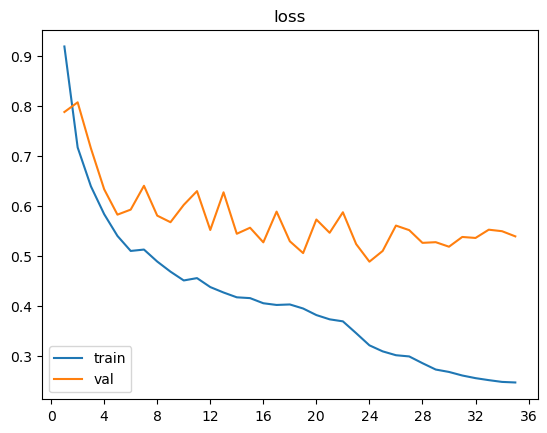

In [10]:
model = PASCode.model.GAT(in_channels=data.x.shape[1], 
                          out_channels=64, num_class=3, heads=4)

best_model = PASCode.model.Trainer(model=model, device='cuda').train(
    trn_data_loader=data_loader, data_val=data, val_data_loader=None,
    max_epoch=100, lr=1e-3, lr_decay=[2, 0.5], early_stopping=10, weight_decay=1e-3)

In [11]:
model = best_model
model.eval()
model.to('cpu')

with torch.no_grad():
    adata.obs['pac_score'] = model.predict(data)

In [12]:
torch.save(best_model.state_dict(), './trained_models/r01_model.pt')
adata.write_h5ad(DATA_PATH + 'contrasts/r01.h5ad')
adata_pac.write_h5ad(DATA_PATH + 'contrasts/r01_30v30_sb.h5ad')